In [1]:
# Spam Email Classifier
### Internship Project using Machine Learning

In [5]:
# Import Liberaries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [13]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [15]:
data = pd.read_excel(r"C:\Users\HP\OneDrive\Documents\spam.csv.xlsx")

data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [17]:
#Keep Required Columns

data = data[['v1', 'v2']]

data.columns = ['label', 'message']

data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
#Convert Labels

data['label'] = data['label'].map({
    'ham': 0,
    'spam': 1
})

In [27]:
#  Define Features

X = data['message'].astype(str)

y = data['label']

In [29]:
# Text Vectorization

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(X)

In [31]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
# Train Model

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [35]:
#  Model Accuracy

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy :", accuracy)

Model Accuracy : 0.97847533632287


In [37]:
# Test Custom Message

message = [
    "Congratulations! You won a free iPhone"
]

message_vector = vectorizer.transform(message)

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Not Spam")

Spam Message


In [39]:
# Insight -1 

print("Dataset Shape:")

print(data.shape)

Dataset Shape:
(5572, 2)


In [41]:
# Insight -2 

print("Spam and Ham Message Count:")

print(data['label'].value_counts())

Spam and Ham Message Count:
label
0    4825
1     747
Name: count, dtype: int64


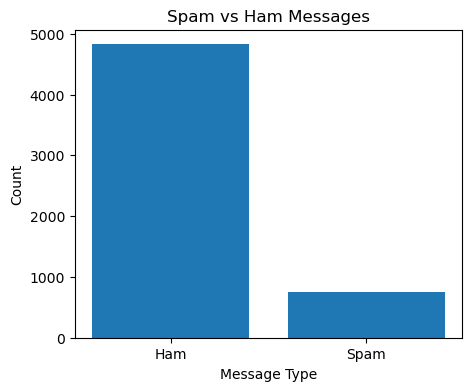

In [43]:
# Graph 

import matplotlib.pyplot as plt

# Count spam and ham messages
counts = data['label'].value_counts()

# Create bar graph
plt.figure(figsize=(5,4))

plt.bar(['Ham', 'Spam'], counts)

plt.title("Spam vs Ham Messages")

plt.xlabel("Message Type")

plt.ylabel("Count")

plt.show()

In [47]:
## Conclusion
###This project successfully classifies spam and non-spam messages using Machine Learning and Natural Language Processing techniques.